In [ ]:
from google.colab import drive # remove the cell if not using colab
drive.mount('/content/drive')
import pandas as pd
import numpy as np
from pathlib import Path
base_path = Path('/content/drive/MyDrive/Data') # Pass path to data folder here, e.g. Path('/content/drive/MyDrive/data') if using Google Drive
import zipfile
import seaborn as sns
import matplotlib.pyplot as plt

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
sks_df=pd.read_parquet(base_path / 'sks_users.parquet')
events_df=pd.read_parquet(base_path / 'pwr_events.parquet')
park_avaib_df=pd.read_parquet(base_path / 'parking_availabilities.parquet')
park_info_df=pd.read_parquet(base_path / 'parkings.parquet')





In [ ]:

events_df.head()

,uid,summary,start,end,location
0,64etqju29vmbvvmfnrdrdcbce1@google.com,Dzień Studenta na W-6,2023-11-17 00:00:00+00:00,2023-11-18 00:00:00+00:00,
1,6th3id9p68p6abb160s66b9k6gqmabb1c9i38bb3cphjeo...,[Studencka Dawka Kultury] Wyjście na Fantastyc...,2018-11-16 18:00:00+00:00,2018-11-16 21:00:00+00:00,
2,3molmc2sfn4jbhi8j55gjnrgfs@google.com,II Wrocławskie Studenckie Sympozjum Chemiczne...,2013-04-13 08:00:00+00:00,2013-04-13 16:00:00+00:00,
3,cdh3ec9pcpj30b9l74p6ab9k6oo3ibb16ss38bb568rj2c...,ATP,2019-10-15 00:00:00+00:00,2019-10-17 00:00:00+00:00,
4,5e5mi83jagqmb7iarfb593pmjh@google.com,Mikołajki W7 - cukierki na kampusie,2017-12-06 00:00:00+00:00,2017-12-07 00:00:00+00:00,


In [ ]:
events_df.head()

,uid,summary,start,end,location
0,64etqju29vmbvvmfnrdrdcbce1@google.com,Dzień Studenta na W-6,2023-11-17 00:00:00+00:00,2023-11-18 00:00:00+00:00,
1,6th3id9p68p6abb160s66b9k6gqmabb1c9i38bb3cphjeo...,[Studencka Dawka Kultury] Wyjście na Fantastyc...,2018-11-16 18:00:00+00:00,2018-11-16 21:00:00+00:00,
2,3molmc2sfn4jbhi8j55gjnrgfs@google.com,II Wrocławskie Studenckie Sympozjum Chemiczne...,2013-04-13 08:00:00+00:00,2013-04-13 16:00:00+00:00,
3,cdh3ec9pcpj30b9l74p6ab9k6oo3ibb16ss38bb568rj2c...,ATP,2019-10-15 00:00:00+00:00,2019-10-17 00:00:00+00:00,
4,5e5mi83jagqmb7iarfb593pmjh@google.com,Mikołajki W7 - cukierki na kampusie,2017-12-06 00:00:00+00:00,2017-12-07 00:00:00+00:00,


In [ ]:
sks_df.head()

,external_timestamp,active_users,moving_average_21,created_at,updated_at
0,2025-02-03 05:25:00+00:00,1,0,2025-02-03 10:25:00.606927+00:00,2025-02-03 22:59:00.896225+00:00
1,2025-02-03 05:30:00+00:00,1,1,2025-02-03 10:25:00.606927+00:00,2025-02-03 22:59:00.896225+00:00
2,2025-02-03 05:35:00+00:00,2,1,2025-02-03 10:25:00.606927+00:00,2025-02-03 22:59:00.896225+00:00
3,2025-02-03 05:40:00+00:00,2,1,2025-02-03 10:25:00.606927+00:00,2025-02-03 22:59:00.896225+00:00
4,2025-02-03 05:45:00+00:00,3,1,2025-02-03 10:25:00.606927+00:00,2025-02-03 22:59:00.896225+00:00


Firstly i will cut the events_df beacause i dont need the data from 2012.....

In [ ]:
data_graniczna=pd.to_datetime("2025-02-03 07:51:01+00:00")
events_df = events_df[
    events_df['end'] >= data_graniczna
].copy()

In [ ]:
starts = events_df['start'].tolist()
ends = events_df['end'].tolist()
def is_active_event(current_time) -> bool: #returns boolean flag for events
    for start, end in zip(starts, ends):
        if start <= current_time < end:
            return True

    return False

This function checks if there is any event from the events_df database.

In [ ]:
park_avaib_df['is_event'] = park_avaib_df['measured_at'].apply(is_active_event)

In [ ]:
sks_df['is_event'] = sks_df['external_timestamp'].apply(is_active_event)

In [ ]:
park_avaib_df['is_event'].unique()

array([False,  True])

In [ ]:
sks_df = sks_df.set_index('external_timestamp').sort_index()

In [ ]:
park_avaib_df=park_avaib_df.set_index('measured_at').sort_index()

In [ ]:
capacity_map = park_info_df.set_index('id')['places']
park_avaib_df['spaces_occupied'] = park_avaib_df['parking_id'].map(capacity_map) - park_avaib_df['spaces_left']

In [ ]:
park_avaib_df.head()

,id,parking_id,spaces_left,trend,created_at,updated_at,is_event,spaces_occupied
measured_at,,,,,,,,
2025-02-03 07:51:01+00:00,1,4,0,0,2025-02-03 07:51:16.203000+00:00,2025-02-03 07:51:16.203000+00:00,False,207
2025-02-03 07:51:01+00:00,2,2,4,0,2025-02-03 07:51:16.217000+00:00,2025-02-03 07:51:16.217000+00:00,False,50
2025-02-03 07:51:01+00:00,3,5,0,0,2025-02-03 07:51:16.228000+00:00,2025-02-03 07:51:16.228000+00:00,False,76
2025-02-03 07:51:01+00:00,4,6,169,-2,2025-02-03 07:51:16.237000+00:00,2025-02-03 07:51:16.237000+00:00,False,132
2025-02-03 07:51:01+00:00,5,7,57,-1,2025-02-03 07:51:16.246000+00:00,2025-02-03 07:51:16.246000+00:00,False,18


In [ ]:
sks_df.head()

,active_users,moving_average_21,created_at,updated_at,is_event
external_timestamp,,,,,
2025-02-02 23:00:00+00:00,1,4,2025-02-03 10:25:00.606927+00:00,2025-02-03 22:59:00.896225+00:00,False
2025-02-02 23:05:00+00:00,1,5,2025-02-03 10:25:00.606927+00:00,2025-02-03 22:59:00.896225+00:00,False
2025-02-02 23:10:00+00:00,1,4,2025-02-03 10:25:00.606927+00:00,2025-02-03 22:59:00.896225+00:00,False
2025-02-02 23:15:00+00:00,0,4,2025-02-03 10:25:00.606927+00:00,2025-02-03 22:59:00.896225+00:00,False
2025-02-02 23:20:00+00:00,0,4,2025-02-03 10:25:00.606927+00:00,2025-02-03 22:59:00.896225+00:00,False


As we can see the Flag seems correct, now i will do analysis both for IQR and n-sigma anomaly detection methods.

In [ ]:
def is_outlier(df, groupby, filter_column=None, window='7D',z_score_sensitivity=2) -> pd.DataFrame:  #takes as input: dataframe, groupby - for eg. spaces_left, filter_columns-used to filter by parking_id, window- for eg. uses last 30D for calculating anomalies, returns updated dataframe
  df=df.copy()

  if filter_column is None:
      temp_dataframe=df[groupby]



  else:
      temp_dataframe=df.groupby(filter_column)[groupby]

  # Clip values to be non-negative before calculating anomalies
  df[groupby] = df[groupby].clip(lower=0)

  rolling_mean = temp_dataframe.transform(lambda x: x.rolling(window, min_periods=1).mean())
  rolling_std = temp_dataframe.transform(lambda x: x.rolling(window, min_periods=1).std())


  Q1 = temp_dataframe.transform(lambda x: x.rolling(window, min_periods=1).quantile(0.25))
  Q3 = temp_dataframe.transform(lambda x: x.rolling(window, min_periods=1).quantile(0.75))
  df['z_score'] = (df[groupby] - rolling_mean) / rolling_std
  df['z_score'] = df['z_score'].fillna(0)
  df['is_outlier_zscore'] = df['z_score'].abs() > z_score_sensitivity
  df['is_event_z_score_outlier']=df['is_outlier_zscore'] & df['is_event']

  df['n_sigma_lower'] = rolling_mean - z_score_sensitivity * rolling_std
  df['n_sigma_lower']=df['n_sigma_lower'].clip(lower=0)

  df['n_sigma_upper'] = rolling_mean + z_score_sensitivity * rolling_std

  IQR = Q3 - Q1
  c = 2
  min_t = Q1 - c*IQR
  max_t = Q3 + c*IQR

  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR


  df['iqr_lower'] = lower_bound
  df['iqr_lower']=df['iqr_lower'].clip(lower=0)

  df['iqr_upper'] = upper_bound

  df['is_outlier_iqr'] = (df[groupby] < lower_bound) | (df[groupby] > upper_bound)

  df['is_event_iqr_outlier']=df['is_outlier_iqr'] & df['is_event']


  df['is_outlier_iqr_z_score']=df['is_outlier_iqr'] & df['is_outlier_zscore']

  df['is_event_iqr_z_score_outlier']=df['is_event'] & df['is_outlier_iqr_z_score']





  return df

In [ ]:
sks_df=is_outlier(sks_df,'active_users',filter_column=None)

In [ ]:
sks_df['is_event_z_score_outlier'].unique()

array([False,  True])

In [ ]:
park_avaib_df=is_outlier(park_avaib_df,'spaces_occupied',filter_column='parking_id')

In [ ]:
park_avaib_df.head()

,id,parking_id,spaces_left,trend,created_at,updated_at,is_event,spaces_occupied,z_score,is_outlier_zscore,is_event_z_score_outlier,n_sigma_lower,n_sigma_upper,iqr_lower,iqr_upper,is_outlier_iqr,is_event_iqr_outlier,is_outlier_iqr_z_score,is_event_iqr_z_score_outlier
measured_at,,,,,,,,,,,,,,,,,,,
2025-02-03 07:51:01+00:00,1,4,0,0,2025-02-03 07:51:16.203000+00:00,2025-02-03 07:51:16.203000+00:00,False,207,0.0,False,False,NaN,NaN,207.0,207.0,False,False,False,False
2025-02-03 07:51:01+00:00,2,2,4,0,2025-02-03 07:51:16.217000+00:00,2025-02-03 07:51:16.217000+00:00,False,50,0.0,False,False,NaN,NaN,50.0,50.0,False,False,False,False
2025-02-03 07:51:01+00:00,3,5,0,0,2025-02-03 07:51:16.228000+00:00,2025-02-03 07:51:16.228000+00:00,False,76,0.0,False,False,NaN,NaN,76.0,76.0,False,False,False,False
2025-02-03 07:51:01+00:00,4,6,169,-2,2025-02-03 07:51:16.237000+00:00,2025-02-03 07:51:16.237000+00:00,False,132,0.0,False,False,NaN,NaN,132.0,132.0,False,False,False,False
2025-02-03 07:51:01+00:00,5,7,57,-1,2025-02-03 07:51:16.246000+00:00,2025-02-03 07:51:16.246000+00:00,False,18,0.0,False,False,NaN,NaN,18.0,18.0,False,False,False,False


In [ ]:
sks_df['is_outlier_iqr'].unique()

array([False,  True])

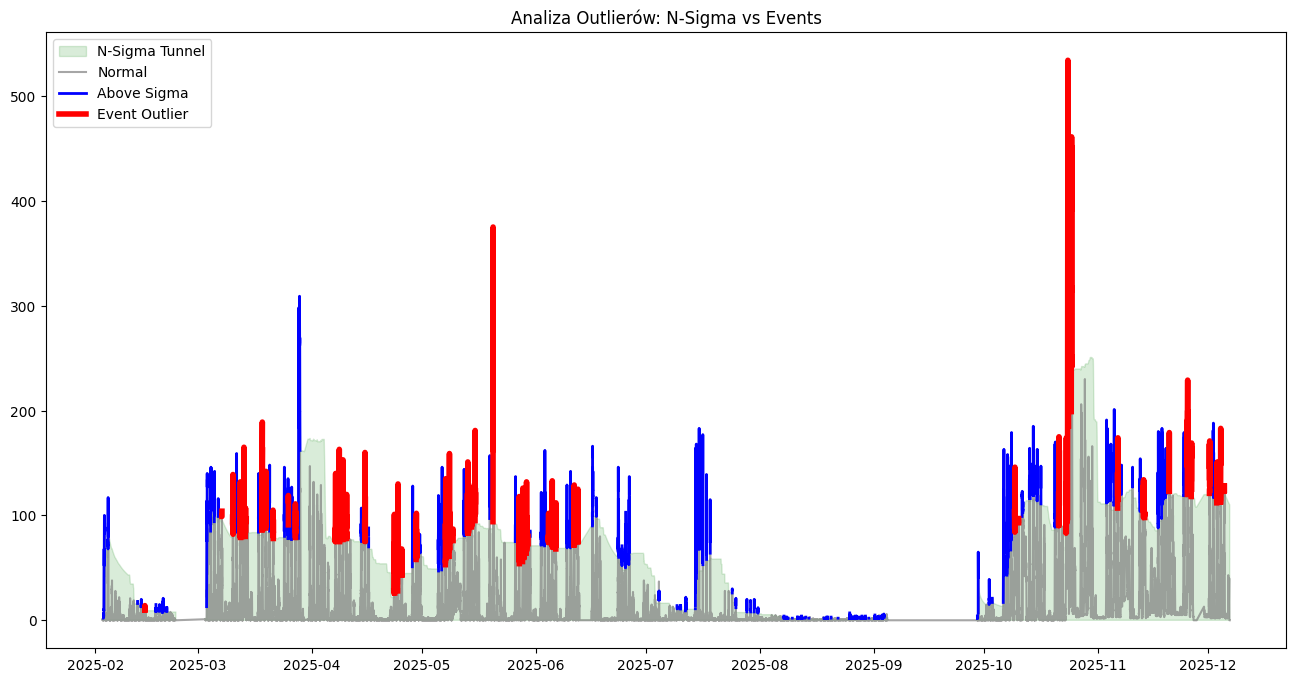

In [ ]:
fig, ax = plt.subplots(figsize=(16,8))


plt.fill_between(sks_df.index, sks_df['n_sigma_lower'], sks_df['n_sigma_upper'],
                 label="N-Sigma Tunnel", color="green", alpha=0.15, zorder=0)


plt.plot(sks_df.index, sks_df['active_users'],
         color="gray", alpha=0.7, label="Normal", zorder=1)



is_blue_condition = (sks_df['active_users'] > sks_df['n_sigma_upper']) & (~sks_df['is_event_z_score_outlier'])

plt.plot(sks_df.index, np.where(is_blue_condition, sks_df['active_users'], np.nan),
         color="blue", linewidth=2, label="Above Sigma", zorder=2)


plt.plot(sks_df.index, np.where(sks_df['is_event_z_score_outlier'], sks_df['active_users'], np.nan),
         color="red", linewidth=4, label="Event Outlier", zorder=3)




plt.legend(loc='upper left')
plt.title("Analiza Outlierów: N-Sigma vs Events")
plt.show()

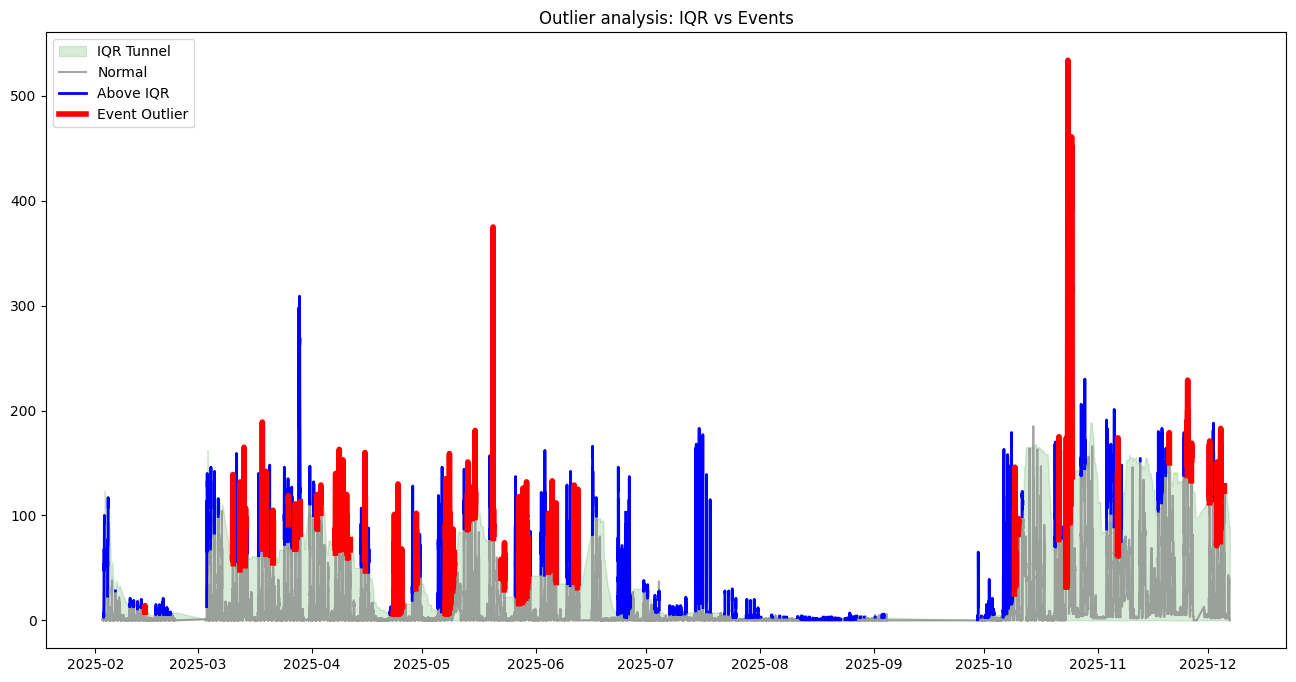

In [ ]:
fig, ax = plt.subplots(figsize=(16,8))


plt.fill_between(sks_df.index, sks_df['iqr_lower'], sks_df['iqr_upper'],
                 label="IQR Tunnel", color="green", alpha=0.15, zorder=0)

plt.plot(sks_df.index, sks_df['active_users'],
         color="gray", alpha=0.7, label="Normal", zorder=1)

is_blue_condition = (sks_df['active_users'] > sks_df['iqr_upper']) & (~sks_df['is_event_iqr_outlier'])

plt.plot(sks_df.index, np.where(is_blue_condition, sks_df['active_users'], np.nan),
         color="blue", linewidth=2, label="Above IQR", zorder=2)


plt.plot(sks_df.index, np.where(sks_df['is_event_iqr_outlier'], sks_df['active_users'], np.nan),
         color="red", linewidth=4, label="Event Outlier", zorder=3)




plt.legend(loc='upper left')
plt.title("Outlier analysis: IQR vs Events")
plt.show()

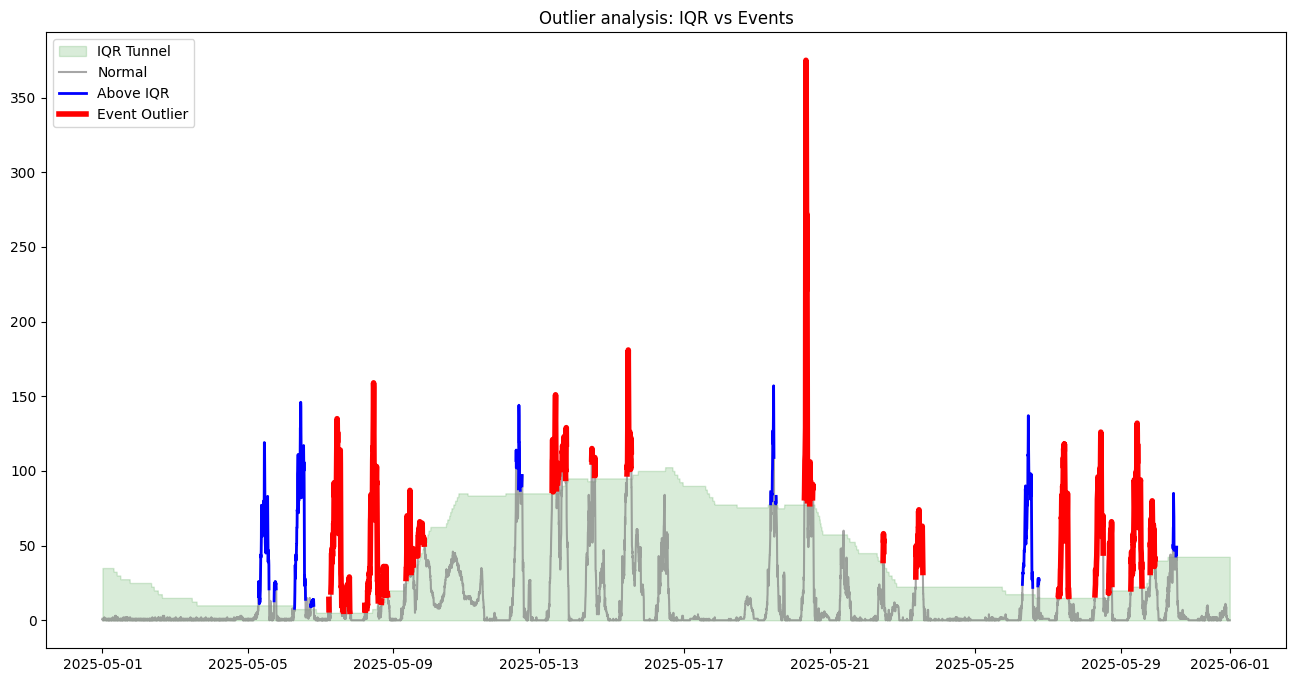

In [ ]:
start_month = '2025-05-01' # Change this to your desired start month (YYYY-MM-DD)
end_month='2025-06-01'
sks_df_filtered = sks_df[(sks_df.index >= start_month) & (sks_df.index < end_month)]

fig, ax = plt.subplots(figsize=(16,8))


plt.fill_between(sks_df_filtered.index, sks_df_filtered['iqr_lower'], sks_df_filtered['iqr_upper'],
                 label="IQR Tunnel", color="green", alpha=0.15, zorder=0)

plt.plot(sks_df_filtered.index, sks_df_filtered['active_users'],
         color="gray", alpha=0.7, label="Normal", zorder=1)

is_blue_condition = (sks_df_filtered['active_users'] > sks_df_filtered['iqr_upper']) & (~sks_df_filtered['is_event_iqr_outlier'])

plt.plot(sks_df_filtered.index, np.where(is_blue_condition, sks_df_filtered['active_users'], np.nan),
         color="blue", linewidth=2, label="Above IQR", zorder=2)


plt.plot(sks_df_filtered.index, np.where(sks_df_filtered['is_event_iqr_outlier'], sks_df_filtered['active_users'], np.nan),
         color="red", linewidth=4, label="Event Outlier", zorder=3)




plt.legend(loc='upper left')
plt.title("Outlier analysis: IQR vs Events")
plt.show()

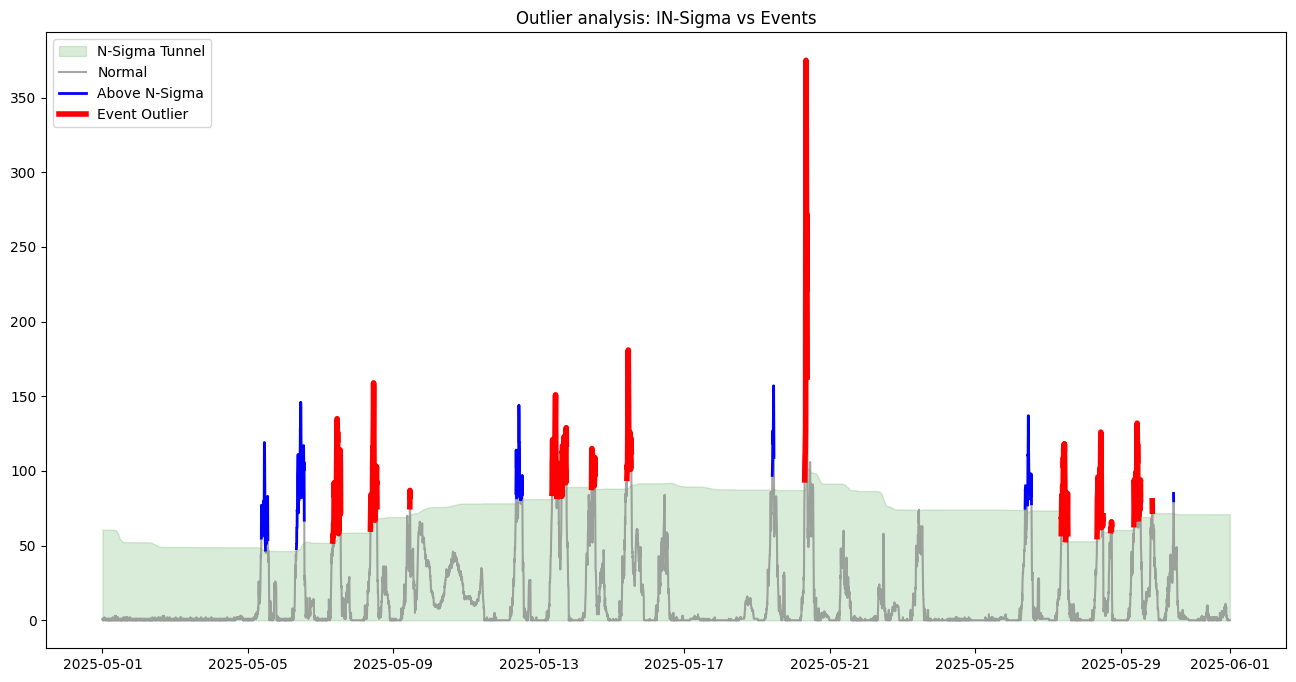

In [ ]:
start_month = '2025-05-01' # Change this to your desired start month (YYYY-MM-DD)
end_month='2025-06-01'
sks_df_filtered = sks_df[(sks_df.index >= start_month) & (sks_df.index < end_month)]

fig, ax = plt.subplots(figsize=(16,8))


plt.fill_between(sks_df_filtered.index, sks_df_filtered['n_sigma_lower'], sks_df_filtered['n_sigma_upper'],
                 label="N-Sigma Tunnel", color="green", alpha=0.15, zorder=0)

plt.plot(sks_df_filtered.index, sks_df_filtered['active_users'],
         color="gray", alpha=0.7, label="Normal", zorder=1)

is_blue_condition = (sks_df_filtered['active_users'] > sks_df_filtered['n_sigma_upper']) & (~sks_df_filtered['is_event_z_score_outlier'])

plt.plot(sks_df_filtered.index, np.where(is_blue_condition, sks_df_filtered['active_users'], np.nan),
         color="blue", linewidth=2, label="Above N-Sigma", zorder=2)


plt.plot(sks_df_filtered.index, np.where(sks_df_filtered['is_event_z_score_outlier'], sks_df_filtered['active_users'], np.nan),
         color="red", linewidth=4, label="Event Outlier", zorder=3)




plt.legend(loc='upper left')
plt.title("Outlier analysis: IN-Sigma vs Events")
plt.show()

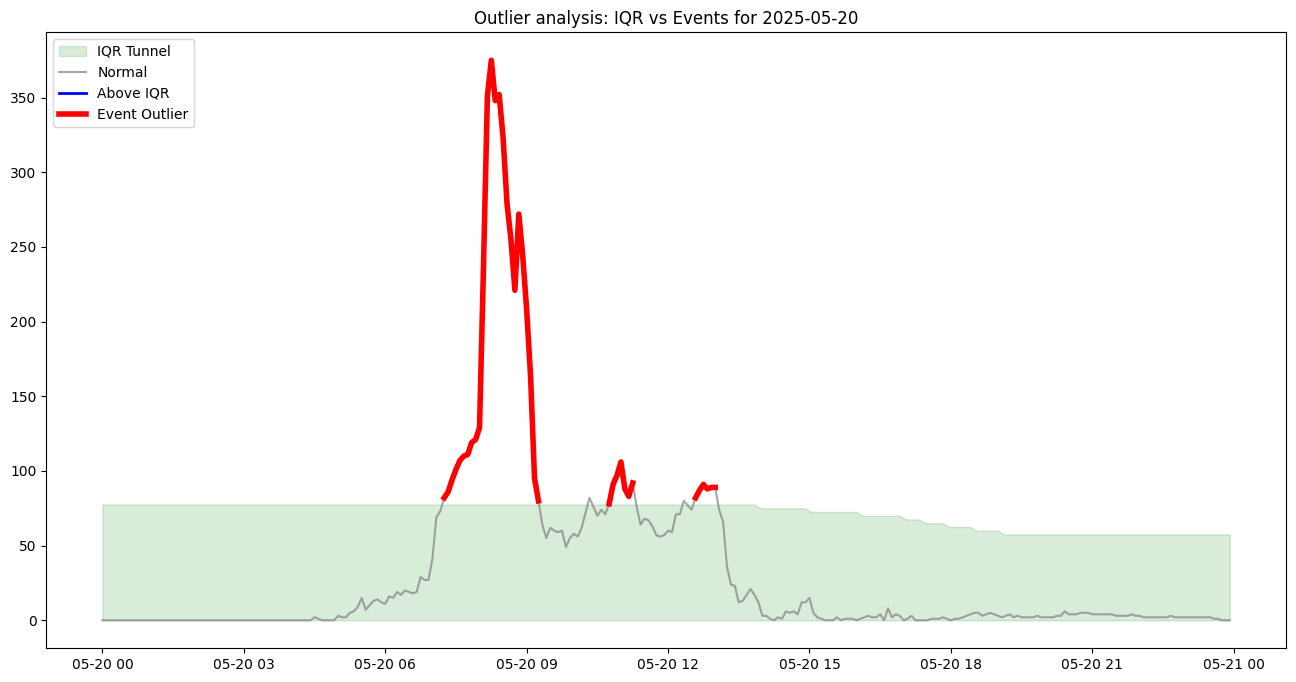

In [ ]:
start_date = '2025-05-20' # Change this to your desired specific date (YYYY-MM-DD)
end_date = (pd.to_datetime(start_date) + pd.Timedelta(days=1)).strftime('%Y-%m-%d')
sks_df_filtered = sks_df[(sks_df.index >= start_date) & (sks_df.index < end_date)]

fig, ax = plt.subplots(figsize=(16,8))


plt.fill_between(sks_df_filtered.index, sks_df_filtered['iqr_lower'], sks_df_filtered['iqr_upper'],
                 label="IQR Tunnel", color="green", alpha=0.15, zorder=0)

plt.plot(sks_df_filtered.index, sks_df_filtered['active_users'],
         color="gray", alpha=0.7, label="Normal", zorder=1)

is_blue_condition = (sks_df_filtered['active_users'] > sks_df_filtered['iqr_upper']) & (~sks_df_filtered['is_event_iqr_outlier'])

plt.plot(sks_df_filtered.index, np.where(is_blue_condition, sks_df_filtered['active_users'], np.nan),
         color="blue", linewidth=2, label="Above IQR", zorder=2)


plt.plot(sks_df_filtered.index, np.where(sks_df_filtered['is_event_iqr_outlier'], sks_df_filtered['active_users'], np.nan),
         color="red", linewidth=4, label="Event Outlier", zorder=3)




plt.legend(loc='upper left')
plt.title(f"Outlier analysis: IQR vs Events for {start_date}")
plt.show()

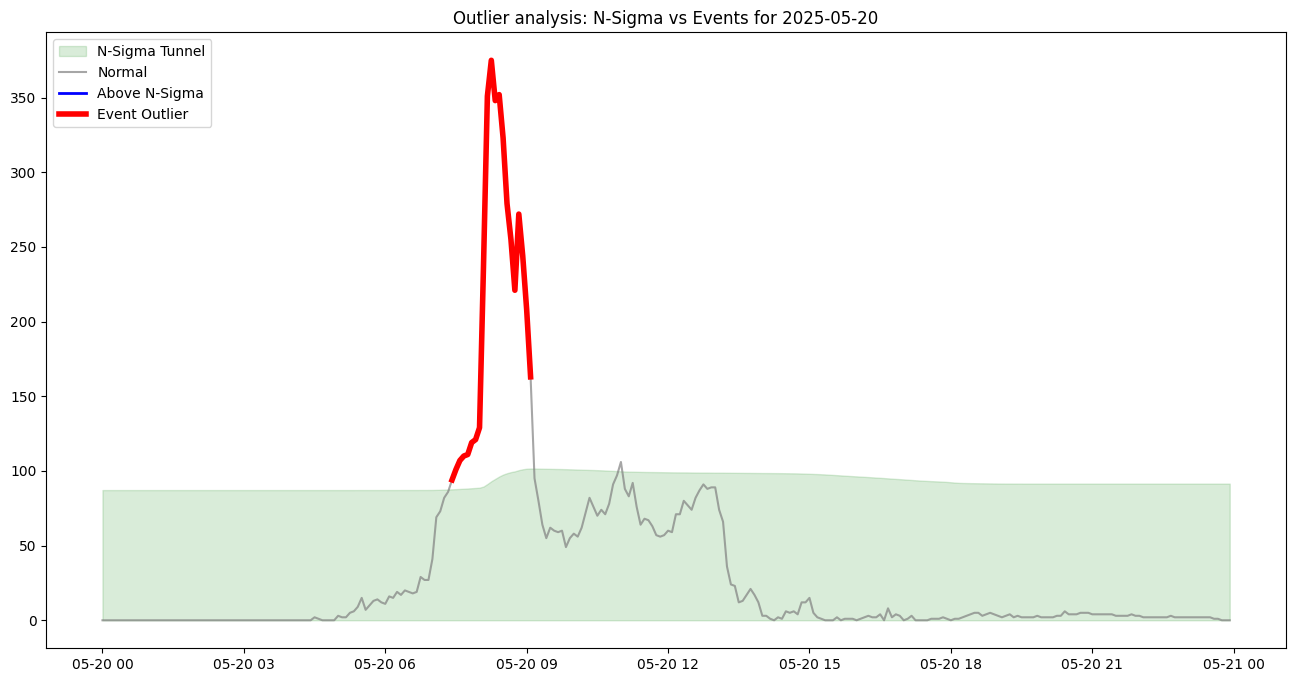

In [ ]:
start_date = '2025-05-20' # Change this to your desired specific date (YYYY-MM-DD)
end_date = (pd.to_datetime(start_date) + pd.Timedelta(days=1)).strftime('%Y-%m-%d')
sks_df_filtered = sks_df[(sks_df.index >= start_date) & (sks_df.index < end_date)]

fig, ax = plt.subplots(figsize=(16,8))


plt.fill_between(sks_df_filtered.index, sks_df_filtered['n_sigma_lower'], sks_df_filtered['n_sigma_upper'],
                 label="N-Sigma Tunnel", color="green", alpha=0.15, zorder=0)

plt.plot(sks_df_filtered.index, sks_df_filtered['active_users'],
         color="gray", alpha=0.7, label="Normal", zorder=1)

is_blue_condition = (sks_df_filtered['active_users'] > sks_df_filtered['n_sigma_upper']) & (~sks_df_filtered['is_event_z_score_outlier'])

plt.plot(sks_df_filtered.index, np.where(is_blue_condition, sks_df_filtered['active_users'], np.nan),
         color="blue", linewidth=2, label="Above N-Sigma", zorder=2)


plt.plot(sks_df_filtered.index, np.where(sks_df_filtered['is_event_z_score_outlier'], sks_df_filtered['active_users'], np.nan),
         color="red", linewidth=4, label="Event Outlier", zorder=3)




plt.legend(loc='upper left')
plt.title(f"Outlier analysis: N-Sigma vs Events for {start_date}")
plt.show()

In [ ]:
results = {
    "Metoda": ["N-Sigma (Z-Score)", "IQR", "Obie"],
    "Suma wykrytych anomalii": [sks_df['is_outlier_zscore'].sum(), sks_df['is_outlier_iqr'].sum(), sks_df['is_outlier_iqr_z_score'].sum()],
    "Anomalie podczas Eventów": [sks_df['is_event_z_score_outlier'].sum(), sks_df['is_event_iqr_outlier'].sum(),sks_df['is_event_iqr_z_score_outlier'].sum()],
    "% Anomalii w Eventach": [
        (sks_df['is_event_z_score_outlier'].sum() / sks_df['is_outlier_zscore'].sum() * 100).round(2),
        (sks_df['is_event_iqr_outlier'].sum() / sks_df['is_outlier_iqr'].sum() * 100).round(2),
        (sks_df['is_event_iqr_z_score_outlier'].sum() / sks_df['is_outlier_iqr_z_score'].sum() * 100).round(2),

    ]
}
comparison_df = pd.DataFrame(results)
display(comparison_df)

,Metoda,Suma wykrytych anomalii,Anomalie podczas Eventów,% Anomalii w Eventach
0,N-Sigma (Z-Score),4799,1747,36.40
1,IQR,8934,3257,36.46
2,Obie,4328,1660,38.35


In [ ]:
both = sks_df[sks_df['is_outlier_zscore'] & sks_df['is_outlier_iqr']].shape[0]
only_zscore = sks_df[sks_df['is_outlier_zscore'] & ~sks_df['is_outlier_iqr']].shape[0]
only_iqr = sks_df[~sks_df['is_outlier_zscore'] & sks_df['is_outlier_iqr']].shape[0]

print(f"Zgoda obu metod: {both} punktów")
print(f"Tylko Z-Score: {only_zscore}")
print(f"Tylko IQR: {only_iqr}")

Zgoda obu metod: 4328 punktów
Tylko Z-Score: 471
Tylko IQR: 4606


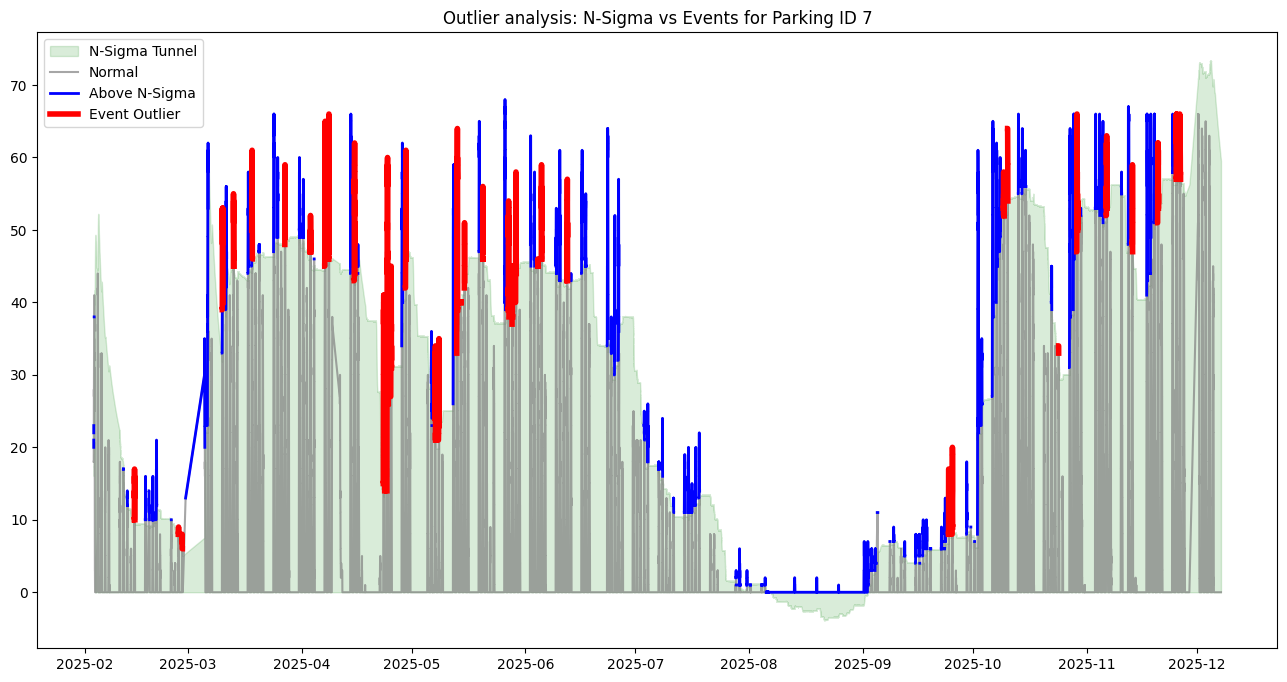

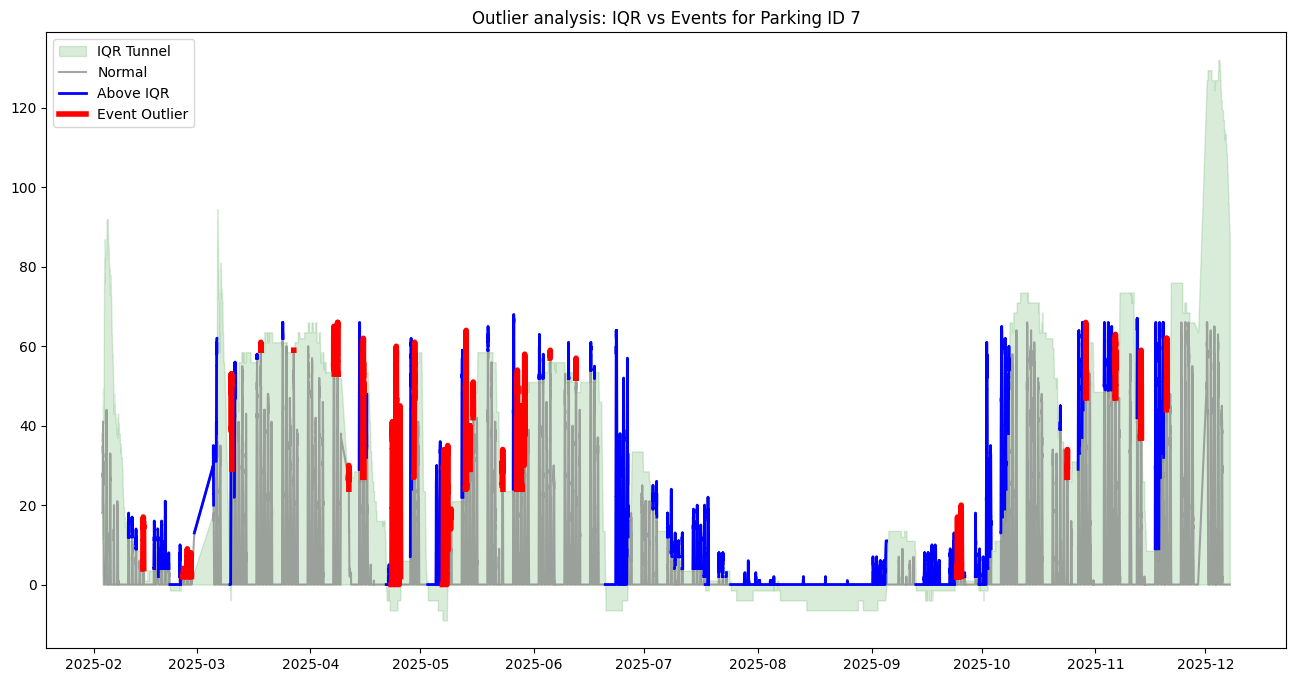

In [ ]:
parking_id_to_plot = 7  # Change this to the desired parking_id

park_df_filtered = park_avaib_df[park_avaib_df['parking_id'] == parking_id_to_plot]

# N-Sigma plot for the selected parking_id
fig, ax = plt.subplots(figsize=(16,8))

plt.fill_between(park_df_filtered.index, park_df_filtered['n_sigma_lower'], park_df_filtered['n_sigma_upper'],
                 label="N-Sigma Tunnel", color="green", alpha=0.15, zorder=0)

plt.plot(park_df_filtered.index, park_df_filtered['spaces_occupied'],
         color="gray", alpha=0.7, label="Normal", zorder=1)

is_blue_condition = (park_df_filtered['spaces_occupied'] > park_df_filtered['n_sigma_upper']) & (~park_df_filtered['is_event_z_score_outlier'])

plt.plot(park_df_filtered.index, np.where(is_blue_condition, park_df_filtered['spaces_occupied'], np.nan),
         color="blue", linewidth=2, label="Above N-Sigma", zorder=2)

plt.plot(park_df_filtered.index, np.where(park_df_filtered['is_event_z_score_outlier'], park_df_filtered['spaces_occupied'], np.nan),
         color="red", linewidth=4, label="Event Outlier", zorder=3)

plt.legend(loc='upper left')
plt.title(f"Outlier analysis: N-Sigma vs Events for Parking ID {parking_id_to_plot}")
plt.show()

# IQR plot for the selected parking_id
fig, ax = plt.subplots(figsize=(16,8))

plt.fill_between(park_df_filtered.index, park_df_filtered['iqr_lower'], park_df_filtered['iqr_upper'],
                 label="IQR Tunnel", color="green", alpha=0.15, zorder=0)

plt.plot(park_df_filtered.index, park_df_filtered['spaces_occupied'],
         color="gray", alpha=0.7, label="Normal", zorder=1)

is_blue_condition = (park_df_filtered['spaces_occupied'] > park_df_filtered['iqr_upper']) & (~park_df_filtered['is_event_iqr_outlier'])

plt.plot(park_df_filtered.index, np.where(is_blue_condition, park_df_filtered['spaces_occupied'], np.nan),
         color="blue", linewidth=2, label="Above IQR", zorder=2)

plt.plot(park_df_filtered.index, np.where(park_df_filtered['is_event_iqr_outlier'], park_df_filtered['spaces_occupied'], np.nan),
         color="red", linewidth=4, label="Event Outlier", zorder=3)

plt.legend(loc='upper left')
plt.title(f"Outlier analysis: IQR vs Events for Parking ID {parking_id_to_plot}")
plt.show()

In [ ]:
print(f"Minimum 'spaces_occupied' for Parking ID {parking_id_to_plot}: {park_df_filtered['spaces_occupied'].min()}")
print(f"Minimum 'n_sigma_lower' for Parking ID {parking_id_to_plot}: {park_df_filtered['n_sigma_lower'].min()}")
print(f"Minimum 'iqr_lower' for Parking ID {parking_id_to_plot}: {park_df_filtered['iqr_lower'].min()}")

Minimum 'spaces_occupied' for Parking ID 7: 0
Minimum 'n_sigma_lower' for Parking ID 7: 0.0
Minimum 'iqr_lower' for Parking ID 7: 0.0
